In [50]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import pandas as pd
from pysr import PySRRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pysindy as ps
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [51]:
g = 9.81
t = np.linspace(0, 5, 100) # Adjusted time range to be more logical for freefall from 100m

h = 100 - 0.5 * g * t**2

df = pd.DataFrame({"t": t, "h": h})

print(df.head())

          t           h
0  0.000000  100.000000
1  0.050505   99.987489
2  0.101010   99.949954
3  0.151515   99.887397
4  0.202020   99.799816


In [52]:
noise_amplitude = 1.0
df['h_noisy'] = df['h'] + np.random.normal(0, noise_amplitude, size=len(df))

print(df.head())

          t           h     h_noisy
0  0.000000  100.000000  100.061069
1  0.050505   99.987489   98.677050
2  0.101010   99.949954   99.001492
3  0.151515   99.887397   99.919673
4  0.202020   99.799816   98.722272


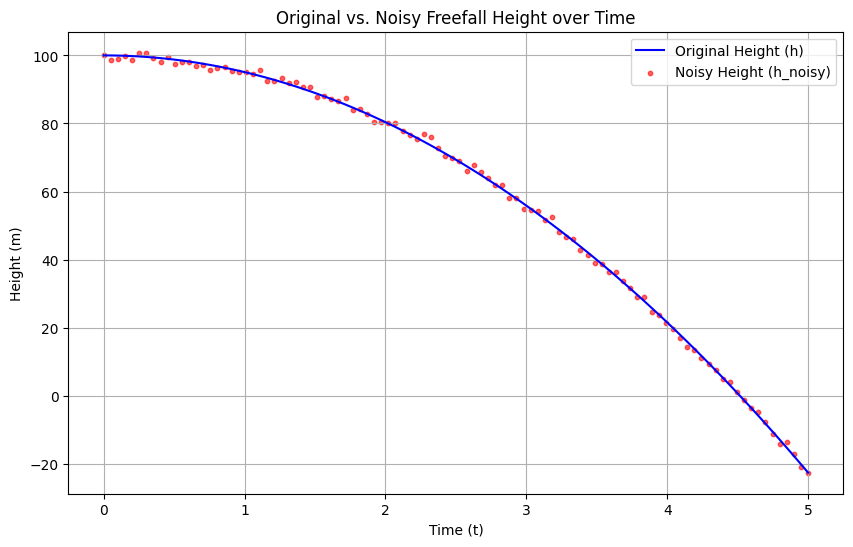

In [53]:
plt.figure(figsize=(10, 6))
plt.plot(df['t'], df['h'], label='Original Height (h)', color='blue')
plt.scatter(df['t'], df['h_noisy'], label='Noisy Height (h_noisy)', color='red', alpha=0.6, s=10)
plt.xlabel('Time (t)')
plt.ylabel('Height (m)')
plt.title('Original vs. Noisy Freefall Height over Time')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
X = df["t"].values.reshape(-1,1)
y = df["h_noisy"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [118]:
pysr_model = PySRRegressor(
    niterations=100,
    binary_operators=["+", "-", "*", "/"],
    unary_operators=["sin", "cos", "exp"],
)

In [119]:
pysr_model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 1.090e+05
Progress: 564 / 3100 total iterations (18.194%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.419e+03  0.000e+00  y = 57.33
3           1.315e+03  3.802e-02  y = 59.893 - x₀
4           1.523e+02  2.156e+00  y = 89.091 - exp(x₀)
5           9.229e+01  5.008e-01  y = (4.8578 - x₀) * 24.984
7           8.324e-01  2.354e+00  y = 99.997 - ((x₀ * 4.9069) * x₀)
9           8.264e-01  3.610e-03  y = ((0.21049 - (x₀ * 4.9456)) * x₀) + 99.794
10          7.932e-01  4.100e-02  y = (sin(x₀) + 99.139) - (x₀ * (x₀ * 4.8222))
12          7.837e-01  6.000e-03  y = (sin(x₀) + 99.394) - (((x₀ - -0.055051) * 4.7739) * x₀...
                                      )
14          7.837e-01  5.662e-07  y = ((sin(x₀) + 99.395) - (x₀ * ((x₀ - -0.26509) * 4.77

[ Info: Final population:
[ Info: Results saved to:


PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          57.330303   
	1         0.038088                                     59.892574 - x0   
	2         2.155887                                 89.09129 - exp(x0)   
	3         0.500847                      121.367744 - (x0 * 24.984293)   
	4   >>>>  2.354225                 99.99712 - (x0 * (x0 * 4.9068537))   
	5         0.003610  99.793686 - (x0 * ((x0 * 4.945684) + -0.211104...   
	6         0.041002     (sin(x0) + 99.13939) - (x0 * (x0 * 4.8221736))   
	7         0.006898  (sin(sin(x0)) + 99.23981) - ((x0 * 4.8328037) ...   
	8         0.005105  (sin(x0) + 99.39456) - (((x0 * 4.773527) + 0.2...   
	9         0.012299  (-0.0371362 / (4.825405 - x0)) + (100.011475 -...   
	10        0.050781  99.99618 - ((x0 * 4.8985004) * ((sin(exp(x0) *...   
	11        0.000004  99.99618 - ((sin(sin(exp(x0) * 52.52572) * -0....   
	12        0.001179  ((sin(exp(sin(sin(x0))) * 33.230583) * 0.53831...   
	13        0.003903  ((sin(sin(exp(sin(sin(x0))) * 33.236813)) * 0....   
	14        0.040311  ((sin(exp(sin(sin(x0 + 0.019874195))) * 33.371...   
	15        0.014100  ((sin(x0 * exp(x0)) * (cos(exp(-1.1565197 / si...   
	16        0.007852  3.6145833 + (((sin(x0 * exp(x0)) * (cos(exp(-1...   
	17        0.022943  (-2.453647 + ((-0.8468488 * cos(exp(-2.162046 ...   
	18        0.006924  (-2.453647 + ((-0.8468488 * cos(exp(-2.162046 ...   
	19        0.004592  (((51.907585 - ((x0 * 2.4915292) * x0)) * 1.97...   
	
	           loss  complexity  
	0   1419.261800           1  
	1   1315.163200           3  
	2    152.296430           4  
	3     92.294230           5  
	4      0.832379           7  
	5      0.826390           9  
	6      0.793192          10  
	7      0.787739          11  
	8      0.783728          12  
	9      0.774148          13  
	10     0.699385          15  
	11     0.699382          16  
	12     0.698558          17  
	13     0.695837          18  
	14     0.668345          19  
	15     0.640663          22  
	16     0.630680          24  
	17     0.602395          26  
	18     0.594110          28  
	19     0.588680          30  
]

  - outputs/20260503_231102_CvcI71/hall_of_fame.csv


In [122]:
best_eq = pysr_model.get_best()
print(best_eq)

complexity                                                 7
loss                                                0.832379
equation                  99.99712 - (x0 * (x0 * 4.9068537))
score                                               2.354225
sympy_format                      99.99712 - 4.9068537*x0*x0
lambda_format    PySRFunction(X=>99.99712 - 4.9068537*x0*x0)
Name: 4, dtype: object


In [123]:
y_pred = pysr_model.predict(X_test)

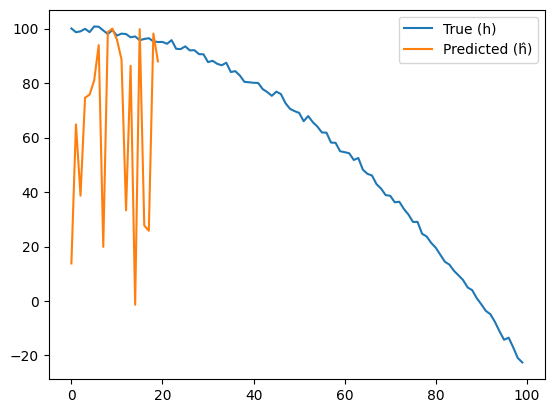

In [59]:
plt.plot(y, label="True (h)")
plt.plot(y_pred, label="Predicted (ĥ)")
plt.legend()
plt.show()

In [63]:
print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 0.8750255278205632


In [124]:
print(pysr_model.latex())

100. - x_{0} x_{0} \cdot 4.91


In [125]:
print(pysr_model.sympy())

99.99712 - 4.9068537*x0*x0


In [66]:
model2 = tf.keras.Sequential()
model2.add(layers.Dense(64, activation="relu", input_shape=(1,)))
model2.add(layers.Dense(64, activation="relu"))
model2.add(layers.Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [67]:
X2 = df['t']
y2 = df['h_noisy']
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

In [68]:
model2.compile(optimizer="adam", loss="mse" , metrics=["mae"])

In [69]:
model2.fit(X_train, y_train, epochs=1000, validation_data=(X_test, y_test))

Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 381ms/step - loss: 4663.3970 - mae: 59.8677 - val_loss: 5290.5244 - val_mae: 64.7499
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4641.7798 - mae: 59.7219 - val_loss: 5269.5781 - val_mae: 64.5659
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4622.3994 - mae: 59.5687 - val_loss: 5247.3027 - val_mae: 64.3695
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4602.2920 - mae: 59.4160 - val_loss: 5223.6729 - val_mae: 64.1598
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 4580.4048 - mae: 59.2553 - val_loss: 5198.8403 - val_mae: 63.9379
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 4557.4438 - mae: 59.0868 - val_loss: 5172.2432 - val_mae: 63.6988
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4532.4585 - mae: 58.8904 - val_loss: 5143.7056 - val_mae: 63.4402
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 4506.6318 - mae: 58.7063 - val_loss: 5113.2378 - val_mae: 63.1615

In [70]:
predict = model2.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step


In [71]:
print("MSE:", mean_squared_error(y_test, predict))

MSE: 0.9398956856696259


In [90]:
X3 = df['t'].values.reshape(-1, 1)
y3 = df['h_noisy'].values
X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

In [91]:
v = np.gradient(h, t)
model3 = ps.SINDy(
    optimizer=ps.STLSQ(threshold=0.1),
    feature_library=ps.PolynomialLibrary(degree=3)
)
X = np.column_stack([h, v])

model3.fit(X, t=t)

/usr/local/lib/python3.12/dist-packages/pysindy/optimizers/stlsq.py:234: UserWarning: Sparsity parameter is too big (0.1) and eliminated all coefficients
  warnings.warn(


SINDy(differentiation_method=FiniteDifference(),
      feature_library=PolynomialLibrary(degree=3), optimizer=STLSQ())

In [97]:
X_test_flat = X_test.flatten()
y_test_flat = y_test.flatten()

sort_indices_test = np.argsort(X_test_flat)

X_test_sorted_array = X_test_flat[sort_indices_test]
y_test_sorted_array = y_test_flat[sort_indices_test]

initial_h = h[0]
initial_v = v[0]
initial_state = np.array([initial_h, initial_v])

simulated_states = model3.simulate(initial_state, t=X_test_sorted_array)

h_simulated = simulated_states[:, 0]

print("Test MSE:", mean_squared_error(y_test_sorted_array, h_simulated))

Test MSE: 2254.838385316745


In [98]:
model3.print()

(x0)' =  1.000 x1
(x1)' =  0.000


In [99]:
model4 = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(1)
])

In [107]:
g = 9.81

def pinn_loss(t, h_true, keras_model):
    t = tf.cast(tf.convert_to_tensor(t), tf.float32)
    h_true = tf.cast(tf.convert_to_tensor(h_true), tf.float32)

    with tf.GradientTape(persistent=True) as tape:
        tape.watch(t)
        h_pred = keras_model(t)

        h_t = tape.gradient(h_pred, t)
        h_tt = tape.gradient(h_t, t)

    data_loss = tf.reduce_mean((h_true - h_pred)**2)
    physics_loss = tf.reduce_mean((h_tt + g)**2)

    return data_loss + physics_loss

In [108]:
optimizer = tf.keras.optimizers.Adam(0.001)

for i in range(1000):
    with tf.GradientTape() as tape:
        loss = pinn_loss(X_train, y_train, model4)

    grads = tape.gradient(loss, model4.trainable_variables)
    optimizer.apply_gradients(zip(grads, model4.trainable_variables))

    if i % 100 == 0:
        print(i, loss.numpy())

0 4761.6455
100 3305.751
200 2736.7603
300 2343.9663
400 2066.9116
500 1870.9965
600 1735.3281
700 1644.2495
800 1585.2742
900 1548.5056


In [110]:
y_pred = model4.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step


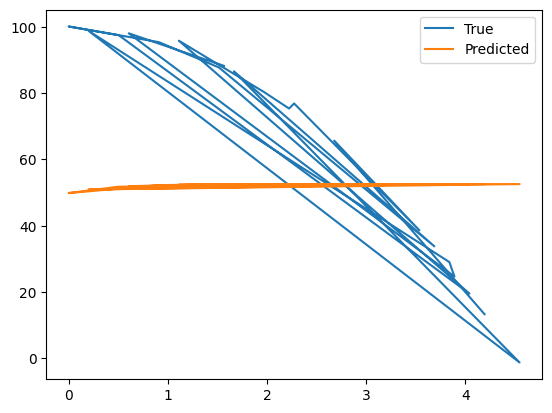

In [111]:
import matplotlib.pyplot as plt

plt.plot(X_test, y_test, label="True")
plt.plot(X_test, y_pred, label="Predicted")
plt.legend()
plt.show()

In [114]:
print("PINN Model MSE:", mean_squared_error(y_test, y_pred))

PINN Model MSE: 1293.997717046273


In [129]:

pysr_y_pred = pysr_model.predict(X_test_sorted_array.reshape(-1, 1))

kern_y_pred = model2.predict(tf.constant(X_test_sorted_array.reshape(-1, 1), dtype=tf.float32))

pinn_y_pred = model4.predict(tf.constant(X_test_sorted_array.reshape(-1, 1), dtype=tf.float32))

sindy_y_pred = h_simulated

comparison_df = pd.DataFrame({
    'Time': X_test_sorted_array.flatten(),
    'True_Noisy_Height': y_test_sorted_array,
    'PySR_Prediction': pysr_y_pred.flatten(),
    'Keras_NN_Prediction': kern_y_pred.flatten(),
    'SINDy_Prediction': sindy_y_pred.flatten(),
    'PINN_Prediction': pinn_y_pred.flatten()
})

print("Comparison DataFrame Head:")
print(comparison_df.head())

csv_filename = 'model_predictions_comparison.csv'
comparison_df.to_csv(csv_filename, index=False)
print(f"\nComparison data saved to {csv_filename}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Comparison DataFrame Head:
       Time  True_Noisy_Height  PySR_Prediction  Keras_NN_Prediction  \
0  0.000000         100.061069        99.997120           101.356186   
1  0.202020          98.722272        99.796861            99.999252   
2  0.505051          97.435185        98.745499            97.963852   
3  0.606061          97.998915        98.194786            97.285385   
4  0.909091          95.344899        95.941869            95.249985   

   SINDy_Prediction  PINN_Prediction  
0        100.000000        49.850368  
1         99.949947        50.924202  
2         99.874867        51.773266  
3         99.849840        51.938419  
4         99.774760        52.244381  

Comparison data saved to model_predictions_comparison.csv


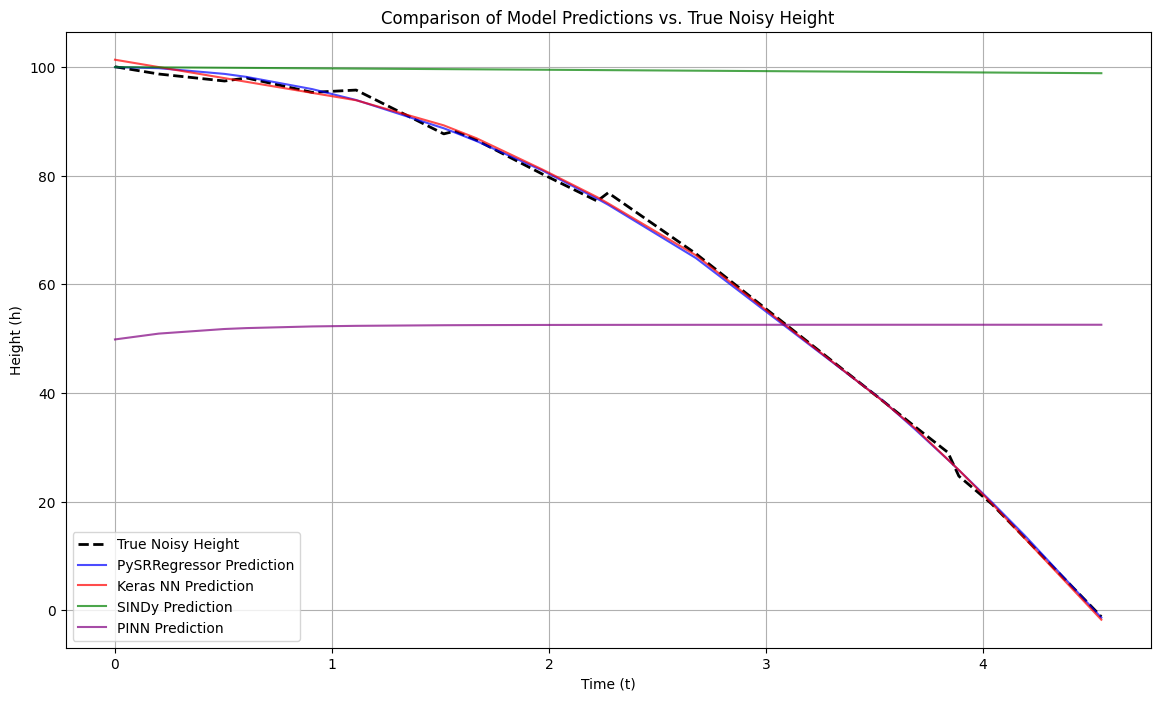

In [130]:
plt.figure(figsize=(14, 8))
plt.plot(comparison_df['Time'], comparison_df['True_Noisy_Height'], label='True Noisy Height', color='black', linestyle='--', linewidth=2)
plt.plot(comparison_df['Time'], comparison_df['PySR_Prediction'], label='PySRRegressor Prediction', color='blue', alpha=0.7)
plt.plot(comparison_df['Time'], comparison_df['Keras_NN_Prediction'], label='Keras NN Prediction', color='red', alpha=0.7)
plt.plot(comparison_df['Time'], comparison_df['SINDy_Prediction'], label='SINDy Prediction', color='green', alpha=0.7)
plt.plot(comparison_df['Time'], comparison_df['PINN_Prediction'], label='PINN Prediction', color='purple', alpha=0.7)

plt.title('Comparison of Model Predictions vs. True Noisy Height')
plt.xlabel('Time (t)')
plt.ylabel('Height (h)')
plt.legend()
plt.grid(True)
plt.show()

### Best Model Equation (PySRRegressor)

As concluded from the previous analysis, the PySRRegressor model achieved the lowest Mean Squared Error and provided an interpretable equation that closely matches the theoretical freefall formula. The best equation found by PySRRegressor is:

In [131]:
print(pysr_model.latex())

100. - x_{0} x_{0} \cdot 4.91


In [132]:
print(pysr_model.sympy())

99.99712 - 4.9068537*x0*x0


This equation `100. - x_{0} x_{0} \cdot 4.91` closely resembles the theoretical freefall equation `h = H0 - 0.5 * g * t^2`, where `H0` is the initial height (approx. 100m), `x0` is time (`t`), and `4.91` is very close to `0.5 * g` (0.5 * 9.81 = 4.905).